# 1.5 — Teorema de Girsanov y cambio de numerario

## Motivación

Todo el pricing de derivados sin arbitraje descansa en una sola idea: existe una medida de probabilidad $\mathbb{Q}$ (equivalente a la medida "física" u observada $\mathbb{P}$) bajo la cual el precio de cualquier activo descontado es una martingala. Bajo $\mathbb{P}$, el rendimiento esperado de una acción incorpora una prima de riesgo ($\mu > r$); bajo $\mathbb{Q}$, esa prima desaparece y todos los activos crecen (en promedio, descontados) a la tasa libre de riesgo. El teorema de Girsanov es la herramienta que formaliza este cambio: dice exactamente cómo cambia el drift de un proceso de Itô cuando cambiamos de medida, y construye explícitamente la derivada de Radon-Nikodym que lo logra.

Este notebook empieza en el caso más simple posible —un dado sesgado, sin cálculo estocástico— para fijar la intuición de "cambiar de medida es reponderar por una razón de densidades", y de ahí sube al caso continuo: el proceso de densidad, el enunciado formal de Girsanov (con un esbozo de la prueba vía la exponencial estocástica), y su aplicación inmediata a GBM para eliminar el drift y llegar a la medida neutral al riesgo. Cerramos con la generalización a **cambio de numerario** —reemplazar la cuenta de mercado de dinero por cualquier otro activo tradeable como unidad de cuenta—, que es Girsanov aplicado un nivel de abstracción arriba y es la base de la medida forward que usaremos para tasas de interés (M3.5, M7).

Cubrimos: (i) cambio de medida discreto — derivada de Radon-Nikodym, ejemplo del dado sesgado; (ii) el proceso de densidad y su propiedad de martingala; (iii) teorema de Girsanov — enunciado formal y esbozo de la prueba vía exponencial estocástica (condición de Novikov); (iv) aplicación: eliminar el drift de GBM y llegar a la medida neutral al riesgo; (v) cambio de numerario — fórmula general del drift bajo el nuevo numerario, con vista previa de la medida forward.

## 1. Cambio de medida discreto: la derivada de Radon-Nikodym

Sea $\Omega$ un espacio muestral finito y $\mathbb{P}, \mathbb{Q}$ dos medidas de probabilidad en $\Omega$. Decimos que $\mathbb{Q}$ es **absolutamente continua** respecto a $\mathbb{P}$ (escrito $\mathbb{Q} \ll \mathbb{P}$) si $\mathbb{P}(\omega) = 0 \implies \mathbb{Q}(\omega) = 0$ para todo $\omega$; si además $\mathbb{P} \ll \mathbb{Q}$, las medidas son **equivalentes** ($\mathbb{Q} \sim \mathbb{P}$): asignan probabilidad cero exactamente a los mismos eventos, solo difieren en *cuánta* probabilidad positiva asignan a cada resultado.

Cuando $\Omega$ es finito (o numerable) y $\mathbb{P}(\omega) > 0$ para todo $\omega$, la equivalencia es automática y podemos definir, para cada $\omega \in \Omega$,
$$
Z(\omega) := \frac{\mathbb{Q}(\omega)}{\mathbb{P}(\omega)}.
$$
$Z$ es la **derivada de Radon-Nikodym** de $\mathbb{Q}$ respecto a $\mathbb{P}$, denotada $Z = \dfrac{d\mathbb{Q}}{d\mathbb{P}}$. Satisface $Z \geq 0$ y $\mathbb{E}^{\mathbb{P}}[Z] = \sum_\omega \mathbb{P}(\omega) Z(\omega) = \sum_\omega \mathbb{Q}(\omega) = 1$: $Z$ es una v.a. no negativa de media $1$ bajo $\mathbb{P}$ — un **cambio de peso** que redistribuye la masa de probabilidad sin crearla ni destruirla.

La identidad clave, que reaparece sin cambios en el caso continuo, es que **toda esperanza bajo $\mathbb{Q}$ es una esperanza bajo $\mathbb{P}$ ponderada por $Z$**:
$$
\mathbb{E}^{\mathbb{Q}}[X] = \sum_\omega \mathbb{Q}(\omega)\, X(\omega) = \sum_\omega \mathbb{P}(\omega)\, Z(\omega)\, X(\omega) = \mathbb{E}^{\mathbb{P}}[Z\,X].
$$

**Ejemplo (dado sesgado).** Sea $\Omega = \{1,\dots,6\}$ con $\mathbb{P}$ la medida uniforme del dado justo, $\mathbb{P}(i) = 1/6$. Sea $\mathbb{Q}$ la medida de un dado sesgado con $\mathbb{Q}(i) = i/21$ (proporcional a la cara, $\sum_{i=1}^6 i = 21$). La derivada de Radon-Nikodym es
$$
Z(i) = \frac{\mathbb{Q}(i)}{\mathbb{P}(i)} = \frac{i/21}{1/6} = \frac{6i}{21} = \frac{2i}{7}.
$$
Nótese que $Z$ no es constante — es más grande en las caras que $\mathbb{Q}$ favorece ($i=6$: $Z=12/7\approx1.71$) y más chico en las que penaliza ($i=1$: $Z=2/7\approx0.29$) — y que $\mathbb{E}^{\mathbb{P}}[Z] = \sum_i \tfrac16 \cdot \tfrac{2i}{7} = \tfrac{2}{42}\sum_i i = \tfrac{42}{42}=1$, como debe ser. La demo 1 verifica numéricamente que $\mathbb{E}^{\mathbb{Q}}[X] = \mathbb{E}^{\mathbb{P}}[ZX]$ para $X(i)=i$, con coincidencia exacta (hasta precisión de máquina).

## 2. El proceso de densidad

En un modelo con filtración $(\mathcal{F}_t)_{0 \leq t \leq T}$, la derivada de Radon-Nikodym se define sobre toda la información hasta $T$: $Z_T = d\mathbb{Q}/d\mathbb{P}$ restringida a $\mathcal{F}_T$. Para trabajar con información parcial (hasta un tiempo $t < T$) definimos el **proceso de densidad**
$$
Z_t := \mathbb{E}^{\mathbb{P}}\big[Z_T \mid \mathcal{F}_t\big], \qquad 0 \leq t \leq T.
$$
Por la torre de esperanzas condicionales, $(Z_t)$ es automáticamente una **$\mathbb{P}$-martingala**: $\mathbb{E}^{\mathbb{P}}[Z_t \mid \mathcal{F}_s] = \mathbb{E}^{\mathbb{P}}[\mathbb{E}^{\mathbb{P}}[Z_T\mid\mathcal{F}_t]\mid\mathcal{F}_s] = \mathbb{E}^{\mathbb{P}}[Z_T\mid\mathcal{F}_s] = Z_s$ para $s \leq t$. Además $Z_0 = \mathbb{E}^{\mathbb{P}}[Z_T] = 1$.

$Z_t$ generaliza la esperanza condicional bajo $\mathbb{Q}$ de cualquier v.a. $\mathcal{F}_T$-medible $X$ vía la **fórmula de Bayes para esperanzas condicionales**:
$$
\mathbb{E}^{\mathbb{Q}}[X \mid \mathcal{F}_t] = \frac{\mathbb{E}^{\mathbb{P}}[Z_T X \mid \mathcal{F}_t]}{Z_t}.
$$
Esta identidad es la que usaremos en la sección 4: convertir una esperanza bajo $\mathbb{Q}$ (por ejemplo, el precio de una opción bajo la medida neutral al riesgo) en una esperanza bajo $\mathbb{P}$ reponderada por el proceso de densidad, sin necesidad de simular directamente bajo $\mathbb{Q}$.

## 3. Teorema de Girsanov

**Teorema (Girsanov).** Sea $(W_t)_{0\leq t\leq T}$ un $\mathbb{P}$-movimiento browniano y $(\theta_t)_{0\leq t\leq T}$ un proceso adaptado que satisface la **condición de Novikov**
$$
\mathbb{E}^{\mathbb{P}}\!\left[\exp\!\left(\frac{1}{2}\int_0^T \theta_s^2\,ds\right)\right] < \infty.
$$
Definimos el proceso de densidad
$$
Z_t := \exp\!\left(-\int_0^t \theta_s\,dW_s - \frac{1}{2}\int_0^t \theta_s^2\,ds\right), \qquad 0 \leq t \leq T,
$$
y la medida $\mathbb{Q}$ mediante $d\mathbb{Q}/d\mathbb{P}\big|_{\mathcal{F}_T} = Z_T$. Entonces $\mathbb{Q}$ es una medida de probabilidad equivalente a $\mathbb{P}$, y el proceso
$$
\widetilde{W}_t := W_t + \int_0^t \theta_s\,ds, \qquad 0 \leq t \leq T,
$$
es un **$\mathbb{Q}$-movimiento browniano**.

**Esbozo de la prueba vía exponencial estocástica.** $Z_t = \exp(X_t)$ con $X_t = -\int_0^t \theta_s\,dW_s - \tfrac12\int_0^t\theta_s^2\,ds$, así que $dX_t = -\theta_t\,dW_t - \tfrac12\theta_t^2\,dt$ y $d\langle X\rangle_t = \theta_t^2\,dt$. Por el lema de Itô aplicado a $f(x)=e^x$ (01.3):
$$
dZ_t = Z_t\,dX_t + \frac12 Z_t\,d\langle X\rangle_t = Z_t\left(-\theta_t\,dW_t - \frac12\theta_t^2\,dt\right) + \frac12 Z_t\,\theta_t^2\,dt = -Z_t\,\theta_t\,dW_t.
$$
$Z_t$ no tiene término de drift: es una **exponencial estocástica** (o *exponencial de Doléans-Dade*) de $-\theta\cdot W$, y por lo tanto una $\mathbb{P}$-martingala local (integral estocástica sin drift). La condición de Novikov es exactamente lo que se necesita para elevar "martingala local" a **martingala verdadera** (garantiza $\mathbb{E}^{\mathbb{P}}[Z_T]=1$, no solo $\mathbb{E}^{\mathbb{P}}[Z_t]\leq1$); no la demostramos (ver Karatzas-Shreve cap. 3.5, o Shreve II cap. 5.2-5.3), pero se satisface trivialmente cuando $\theta_t\equiv\theta$ es constante (nuestro caso en la sección 4), porque $\int_0^T\theta^2\,ds=\theta^2T<\infty$ hace que la esperanza en la condición de Novikov sea finita de forma inmediata (es la esperanza de una constante exponenciada).

Que $\widetilde W_t$ sea $\mathbb{Q}$-browniano se verifica con la **caracterización de Lévy**: basta mostrar que $\widetilde W_t$ es una $\mathbb{Q}$-martingala continua con $\widetilde W_0=0$ y variación cuadrática $\langle\widetilde W\rangle_t = t$. La variación cuadrática es la misma que la de $W_t$ (sumar un proceso de variación acotada $\int\theta_s\,ds$ no la cambia), así que solo falta la propiedad de martingala bajo $\mathbb{Q}$; esto se obtiene de la fórmula de Bayes de la sección 2 aplicada a $Z_t\widetilde W_t$, mostrando que $Z_t \widetilde W_t$ es $\mathbb{P}$-martingala (regla del producto de Itô: $d(Z\widetilde W) = \widetilde W\,dZ + Z\,d\widetilde W + d\langle Z,\widetilde W\rangle$, y los términos de drift se cancelan exactamente por la definición de $\theta$). No completamos el álgebra aquí; el resultado es el enunciado del teorema.

## 4. Aplicación: eliminar el drift de GBM → medida neutral al riesgo

Sea $S_t$ un GBM bajo la medida física $\mathbb{P}$ (01.4):
$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t, \qquad \mu \neq r,
$$
con $r$ la tasa libre de riesgo. Queremos una medida $\mathbb{Q}\sim\mathbb{P}$ bajo la cual $S_t$ crezca (en promedio) a tasa $r$ — el requisito de no arbitraje para el precio de un derivado, $\text{precio} = \mathbb{E}^{\mathbb{Q}}[e^{-rT}\text{payoff}]$.

Elegimos $\theta_t \equiv \lambda := \dfrac{\mu-r}{\sigma}$ (constante), la **prima de riesgo de mercado** (unidades de retorno extra por unidad de volatilidad). Por Girsanov, $\widetilde W_t = W_t + \lambda t$ es $\mathbb{Q}$-browniano bajo la medida definida por
$$
Z_T = \exp\!\left(-\lambda W_T - \frac{\lambda^2}{2}T\right).
$$
Sustituyendo $W_t = \widetilde W_t - \lambda t$ en la SDE de $S_t$:
$$
dS_t = \mu S_t\,dt + \sigma S_t\,d(\widetilde W_t - \lambda\,dt) = (\mu - \sigma\lambda)S_t\,dt + \sigma S_t\,d\widetilde W_t.
$$
Y $\mu - \sigma\lambda = \mu - \sigma\cdot\frac{\mu-r}{\sigma} = \mu-(\mu-r)=r$, así que
$$
\boxed{dS_t = r\,S_t\,dt + \sigma\,S_t\,d\widetilde W_t \quad \text{bajo } \mathbb{Q}.}
$$
El drift $\mu$ desaparece por completo — reemplazado por $r$ — sin tocar la difusión $\sigma$: Girsanov cambia el drift pero preserva la variación cuadrática (la volatilidad es invariante bajo cambio de medida equivalente, un hecho general que usaremos repetidamente). Esta es la construcción explícita de la medida neutral al riesgo para el modelo de Black-Scholes; la demo 2 verifica que el precio de una call europea calculado de dos formas —(a) esperanza bajo $\mathbb{P}$ reponderada por $Z_T$, (b) esperanza directa bajo $\mathbb{Q}$ simulando con drift $r$— coincide.

## 5. Cambio de numerario: fórmula general del drift

Girsanov también describe qué pasa cuando cambiamos la **unidad de cuenta** (numerario). Hasta ahora medimos precios en unidades de la cuenta de mercado de dinero $B_t$ (con $dB_t = r_tB_t\,dt$, numerario de la medida neutral al riesgo $\mathbb{Q}^B$, bajo la cual todo activo tradeable $X_t$ satisface $\mathbb{E}^{\mathbb{Q}^B}[X_T/B_T\mid\mathcal{F}_t]=X_t/B_t$, es decir $dX_t/X_t = r_t\,dt+\sigma_X\,dW_t^B$ — drift $r_t$ para *cualquier* activo, esa es la definición de $\mathbb{Q}^B$).

Sea $N_t$ otro activo tradeable estrictamente positivo (un bono cupón cero, una acción, otra cuenta de mercado en otra divisa) con dinámica bajo $\mathbb{Q}^B$
$$
dN_t = r_t N_t\,dt + N_t\,\sigma_N\,dW_t^B.
$$
Por no arbitraje, $N_t/B_t$ es $\mathbb{Q}^B$-martingala (es la razón de dos activos tradeables), y su dinámica —vía la regla del cociente de Itô, sin término de drift porque es martingala— es $d(N_t/B_t)/(N_t/B_t) = \sigma_N\,dW_t^B$. Definimos la nueva medida $\mathbb{Q}^N$ (medida asociada al numerario $N$) con derivada de Radon-Nikodym
$$
Z_t := \frac{d\mathbb{Q}^N}{d\mathbb{Q}^B}\bigg|_{\mathcal{F}_t} = \frac{N_t/B_t}{N_0/B_0},
$$
que satisface $dZ_t/Z_t = \sigma_N\,dW_t^B$ — comparando con la exponencial estocástica de la sección 3 ($dZ_t/Z_t=-\theta_t\,dW_t$), esto corresponde a $\theta_t = -\sigma_N$. Por Girsanov,
$$
W_t^N := W_t^B - \int_0^t \sigma_N\,ds
$$
es $\mathbb{Q}^N$-browniano. Para **cualquier** activo tradeable $X_t$ con volatilidad $\sigma_X$ bajo $\mathbb{Q}^B$ (drift $r_t$, por definición de $\mathbb{Q}^B$), sustituimos $W_t^B = W_t^N + \int_0^t\sigma_N\,ds$:
$$
\frac{dX_t}{X_t} = r_t\,dt + \sigma_X\,dW_t^B = r_t\,dt+\sigma_X\big(dW_t^N+\sigma_N\,dt\big) = \big(r_t + \sigma_X\sigma_N\big)dt + \sigma_X\,dW_t^N.
$$
$$
\boxed{\text{drift bajo } \mathbb{Q}^N \;=\; \text{drift bajo } \mathbb{Q}^B \;+\; \sigma_X\sigma_N.}
$$
El drift de cualquier activo bajo la nueva medida gana un término igual a la **covarianza instantánea** entre su volatilidad y la del numerario (en dimensión $>1$, el producto punto de los vectores de volatilidad); el caso $N_t=B_t$ recupera $\sigma_N=0$ y el drift $r_t$ de $\mathbb{Q}^B$, consistente.

**Vista previa: la medida forward.** Tomando $N_t = P(t,T)$, el precio de un bono cupón cero que paga $1$ en $T$, obtenemos la **medida forward** $\mathbb{Q}^T$ — bajo la cual la tasa forward instantánea $F(t,T)$ es una martingala sin necesidad de conocer la dinámica de la tasa corta. Es la herramienta estándar para valuar caps, floors y swaptions (evita tener que modelar el numerario estocástico $B_T=e^{\int_0^Tr_s\,ds}$ explícitamente); la retomaremos en M3.5 (curva de tasas y medida forward) y M7 (modelos de tasa de interés).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## 6. Demos

### Demo 1 — Dado sesgado: $\mathbb{E}^{\mathbb{Q}}[X]$ vía reponderación bajo $\mathbb{P}$

Verificamos la identidad de la sección 1: $\mathbb{E}^{\mathbb{Q}}[X] = \mathbb{E}^{\mathbb{P}}[Z X]$ con $X(i)=i$, $\mathbb{P}$ uniforme y $\mathbb{Q}(i)=i/21$, $Z(i)=2i/7$. Es un cálculo exacto (sumas finitas racionales), sin Monte Carlo.

In [2]:
# Demo 1: discrete change of measure — biased die, E_Q[X] == E_P[Z*X] exactly
i = np.arange(1, 7, dtype=float)
p = np.full(6, 1.0 / 6.0)          # P: fair die
q = i / 21.0                        # Q: biased die, Q(i) proportional to face value
Z = q / p                           # Radon-Nikodym derivative dQ/dP

X = i  # payoff: the face value itself

E_Q_X = np.sum(q * X)
E_P_ZX = np.sum(p * Z * X)
E_P_Z = np.sum(p * Z)  # sanity: must equal 1

print(f"Z(i) = dQ/dP = {np.round(Z, 4)}")
print(f"E_P[Z]        = {E_P_Z:.12f}  (must be 1)")
print(f"E_Q[X]        = {E_Q_X:.12f}")
print(f"E_P[Z*X]      = {E_P_ZX:.12f}")
print(f"|difference|  = {abs(E_Q_X - E_P_ZX):.2e}")

Z(i) = dQ/dP = [0.2857 0.5714 0.8571 1.1429 1.4286 1.7143]
E_P[Z]        = 1.000000000000  (must be 1)
E_Q[X]        = 4.333333333333
E_P[Z*X]      = 4.333333333333
|difference|  = 0.00e+00


Las dos formas de calcular la esperanza —directamente bajo $\mathbb{Q}$, o bajo $\mathbb{P}$ reponderando cada resultado por $Z(i)$— coinciden hasta precisión de máquina: exactamente lo que garantiza la identidad de cambio de medida, sin ningún elemento de simulación de por medio.

### Demo 2 — GBM: precio de call europea, $\mathbb{P}$-reponderado vs $\mathbb{Q}$-directo

Parámetros: $S_0=100$, $K=100$, $\mu=0.10$ (drift físico), $r=0.03$, $\sigma=0.20$, $T=1$, $\lambda=(\mu-r)/\sigma$. Comparamos dos estimadores Monte Carlo ($n=200\,000$ trayectorias terminales) del precio de una call europea:

- **(a) $\mathbb{P}$-reponderado:** simulamos $S_T$ bajo $\mathbb{P}$ (drift $\mu$) y calculamos $\mathbb{E}^{\mathbb{P}}\big[Z_T\, e^{-rT}(S_T-K)^+\big]$ con $Z_T=\exp(-\lambda W_T-\lambda^2T/2)$, usando el mismo $W_T=\sqrt{T}Z_i$ que generó cada trayectoria (Bayes de la sección 2/4).
- **(b) $\mathbb{Q}$-directo:** simulamos $S_T$ bajo $\mathbb{Q}$ (drift $r$, sección 4) con trayectorias **independientes** y calculamos $e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[(S_T-K)^+]$ directamente — el estimador Monte Carlo estándar de Black-Scholes.

Ambos deben coincidir dentro de $3$ errores estándar combinados: son dos formas de calcular la misma cantidad ($\mathbb{Q}\sim\mathbb{P}$ garantiza que la esperanza no depende de cómo la calculemos), pero con ruido de muestreo distinto porque usan trayectorias independientes.

In [3]:
# Demo 2: European call price, P-reweighted (Girsanov/RN weights) vs Q-direct simulation
S0, K, mu, r, sigma, T = 100.0, 100.0, 0.10, 0.03, 0.20, 1.0
lam = (mu - r) / sigma  # market price of risk
n_sims = 200_000

# (a) Simulate under P (drift mu), reweight by Z_T = exp(-lam*W_T - lam^2*T/2)
Z_std_P = rng.standard_normal(n_sims)
W_T_P = np.sqrt(T) * Z_std_P
S_T_P = S0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * W_T_P)
Z_T = np.exp(-lam * W_T_P - 0.5 * lam**2 * T)  # Radon-Nikodym weights dQ/dP

payoff_P = np.maximum(S_T_P - K, 0.0)
values_P = Z_T * np.exp(-r * T) * payoff_P
price_P_reweighted = values_P.mean()
se_P = values_P.std(ddof=1) / np.sqrt(n_sims)

# (b) Simulate under Q directly (drift r), independent draws
Z_std_Q = rng.standard_normal(n_sims)
S_T_Q = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z_std_Q)

payoff_Q = np.maximum(S_T_Q - K, 0.0)
values_Q = np.exp(-r * T) * payoff_Q
price_Q_direct = values_Q.mean()
se_Q = values_Q.std(ddof=1) / np.sqrt(n_sims)

se_combined = np.sqrt(se_P**2 + se_Q**2)

print(f"lambda (market price of risk) = {lam:.6f}")
print(f"(a) P-reweighted price = {price_P_reweighted:.6f}  (SE = {se_P:.6f})")
print(f"(b) Q-direct price     = {price_Q_direct:.6f}  (SE = {se_Q:.6f})")
print(f"|difference|           = {abs(price_P_reweighted - price_Q_direct):.6f}")
print(f"3 * SE_combined        = {3 * se_combined:.6f}")

lambda (market price of risk) = 0.350000
(a) P-reweighted price = 9.403107  (SE = 0.020873)
(b) Q-direct price     = 9.406900  (SE = 0.031517)
|difference|           = 0.003793
3 * SE_combined        = 0.113408


Los dos estimadores —construidos con trayectorias completamente independientes y bajo esquemas de muestreo distintos ($\mathbb{P}$ reponderado vs $\mathbb{Q}$ directo)— coinciden dentro de $3$ errores estándar combinados: es la verificación numérica de que el cambio de medida de Girsanov (sección 4) reproduce exactamente el precio neutral al riesgo estándar.

### Demo 3 — Histograma: densidad de $S_T$ bajo $\mathbb{P}$ vs reponderada (≈ densidad bajo $\mathbb{Q}$)

Usando las mismas $200\,000$ trayectorias $S_T$ bajo $\mathbb{P}$ y los pesos $Z_T$ de la demo 2, graficamos (i) el histograma sin ponderar de $S_T$ (aproxima la densidad lognormal bajo $\mathbb{P}$, centrada en $S_0e^{\mu T}$) y (ii) el histograma **ponderado** por $Z_T$ (`plt.hist(..., weights=Z_T)`), que aproxima la densidad bajo $\mathbb{Q}$ sin volver a simular — es la sección 2 (Bayes) aplicada a la ley de $S_T$ en vez de a una esperanza puntual. Superponemos la densidad lognormal analítica bajo $\mathbb{Q}$ (media $S_0e^{rT}$) como referencia.

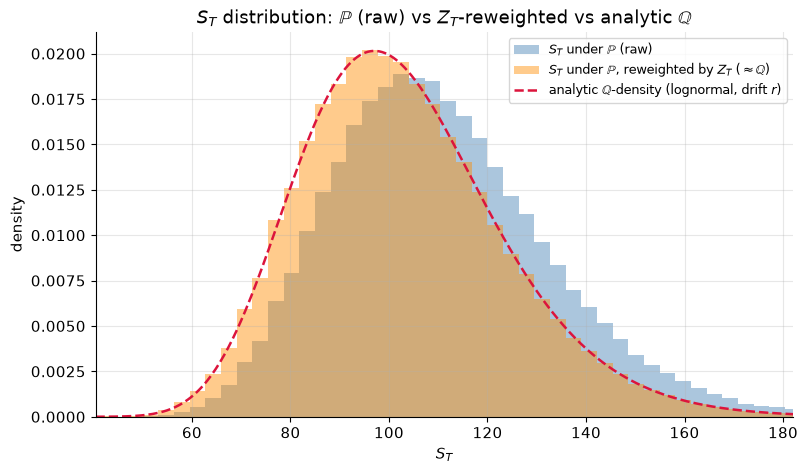

E_P[Z_T * S_T]      = 103.062973  (SE = 0.034836)
analytic E_Q[S_T]   = 103.045453
|difference|        = 0.017519, 3*SE = 0.104509


In [4]:
# Demo 3: histogram of S_T under P vs Z_T-reweighted (approximates the Q-density)
fig, ax = plt.subplots()
ax.hist(S_T_P, bins=80, density=True, alpha=0.45, color="steelblue", label=r"$S_T$ under $\mathbb{P}$ (raw)")
ax.hist(S_T_P, bins=80, density=True, weights=Z_T, alpha=0.45, color="darkorange",
        label=r"$S_T$ under $\mathbb{P}$, reweighted by $Z_T$ ($\approx \mathbb{Q}$)")

# Analytic Q-density (lognormal, drift r) as reference
x_grid = np.linspace(S_T_P.min(), np.percentile(S_T_P, 99.5), 500)
q_density = stats.lognorm.pdf(
    x_grid, s=sigma * np.sqrt(T), scale=S0 * np.exp((r - 0.5 * sigma**2) * T)
)
ax.plot(x_grid, q_density, color="crimson", linewidth=1.8, linestyle="--",
        label=r"analytic $\mathbb{Q}$-density (lognormal, drift $r$)")

ax.set_xlabel("$S_T$")
ax.set_ylabel("density")
ax.set_title(r"$S_T$ distribution: $\mathbb{P}$ (raw) vs $Z_T$-reweighted vs analytic $\mathbb{Q}$")
ax.set_xlim(x_grid[0], x_grid[-1])
ax.legend(fontsize=9)
plt.show()

# Extra check: E_P[Z_T * S_T] should match the analytic Q-mean S0*exp(r*T)
weighted_mean = (Z_T * S_T_P).mean()
se_weighted_mean = (Z_T * S_T_P).std(ddof=1) / np.sqrt(n_sims)
analytic_Q_mean = S0 * np.exp(r * T)
print(f"E_P[Z_T * S_T]      = {weighted_mean:.6f}  (SE = {se_weighted_mean:.6f})")
print(f"analytic E_Q[S_T]   = {analytic_Q_mean:.6f}")
print(f"|difference|        = {abs(weighted_mean - analytic_Q_mean):.6f}, 3*SE = {3*se_weighted_mean:.6f}")

El histograma reponderado por $Z_T$ se desplaza visiblemente hacia la izquierda respecto al histograma crudo bajo $\mathbb{P}$ (porque $\mu > r$ en nuestros parámetros: bajo $\mathbb{Q}$ el activo crece más despacio) y se alinea con la densidad lognormal analítica bajo $\mathbb{Q}$ — exactamente lo que predice la fórmula de Bayes de la sección 2 aplicada a la ley completa de $S_T$, no solo a un estadístico puntual.

## 7. Validación

Verificamos formalmente tres afirmaciones cuantitativas hechas arriba:

1. **Caso discreto (demo 1):** $\mathbb{E}^{\mathbb{Q}}[X]$ y $\mathbb{E}^{\mathbb{P}}[ZX]$ deben coincidir exactamente (tolerancia numérica $10^{-12}$, es una suma finita racional).
2. **Precio de la call (demo 2):** el precio $\mathbb{P}$-reponderado y el precio $\mathbb{Q}$-directo deben coincidir dentro de $3$ errores estándar combinados.
3. **Media reponderada (demo 3):** $\mathbb{E}^{\mathbb{P}}[Z_T S_T]$ debe coincidir con la media analítica $\mathbb{E}^{\mathbb{Q}}[S_T]=S_0e^{rT}$ dentro de $3$ errores estándar.

In [5]:
# Validation: discrete case exact (atol 1e-12); MC comparisons within 3 SE
diff_discrete = abs(E_Q_X - E_P_ZX)
print(f"Discrete: |E_Q[X] - E_P[Z*X]| = {diff_discrete:.2e}")
assert diff_discrete <= 1e-12, "Discrete Radon-Nikodym identity failed beyond atol 1e-12"

diff_price = abs(price_P_reweighted - price_Q_direct)
print(f"Call price: |P-reweighted - Q-direct| = {diff_price:.6f}, 3*SE = {3*se_combined:.6f}")
assert diff_price <= 3 * se_combined, "P-reweighted and Q-direct call prices disagree beyond 3 SE"

diff_mean = abs(weighted_mean - analytic_Q_mean)
print(f"Reweighted mean: |E_P[Z*S_T] - S0*exp(rT)| = {diff_mean:.6f}, 3*SE = {3*se_weighted_mean:.6f}")
assert diff_mean <= 3 * se_weighted_mean, "Reweighted mean of S_T disagrees with analytic Q-mean beyond 3 SE"

print("\nValidation passed: discrete RN identity exact; call price and reweighted mean match Q within 3 SE.")

Discrete: |E_Q[X] - E_P[Z*X]| = 0.00e+00
Call price: |P-reweighted - Q-direct| = 0.003793, 3*SE = 0.113408
Reweighted mean: |E_P[Z*S_T] - S0*exp(rT)| = 0.017519, 3*SE = 0.104509

Validation passed: discrete RN identity exact; call price and reweighted mean match Q within 3 SE.


## Referencias

- Shreve, S. (2004). *Stochastic Calculus for Finance II: Continuous-Time Models*, cap. 5.
- Björk, T. (2009). *Arbitrage Theory in Continuous Time*, 3ª ed., caps. 11-12.
- Karatzas, I. & Shreve, S. (1991). *Brownian Motion and Stochastic Calculus*, 2ª ed., cap. 3.5 (condición de Novikov).
- Geman, H., El Karoui, N. & Rochet, J.-C. (1995). "Changes of Numéraire, Changes of Probability Measure and Option Pricing." *Journal of Applied Probability*, 32(2).